# LLM Inner Structure Analysis with Mesh grid
## Process Overview
1. Load any complex LLM (like LLAMA) and analysis it's architecture
2. Extract the final layer in LLM which performs the softmax. (MLP or Fully connected NN)
3. Now sample the input vectors, similar to p a mesh gird.
  - Since it's difficult to sample 100 points in each of 500 direction, let's fix all the points to some value except 2 or 3. Now sample points from these direction by dividing the scale into 100 points.
4. Now perform classification to predict the next word for a given input vector.
5. When you plot this in the mesh gird, you might see clusters which corresponds to a token.
Now count the number of these mesh grid point inside each cluster and do the similar statistics.

## Statistics
1. Point counts
  - Save the count in a vector. Rearrange them, and plot the count in y-axis and matrix index in the x-axis.
  - Also plot the log log plot using the count matrix.
  - Fit the log log plot with linear line and get the slope.
2. Cluster counts
  - Find the number of clusters with a given size. Ex. 5 clusters has 3 points in them, 7 clusters have 2 points in them...
  - Save the (number of clusters) count in a vector. Rearrange them, and plot the count in y-axis and matrix index in the x-axis.
  - Also plot the log log plot using the count matrix.
  - Fit the log log plot with linear line and get the slope.


### 1. Data & Model Load

In [ ]:
# use wikipedia dataset
import json

filename = "/content/wikipedia_1000_sentences.json"
with open(filename, "r", encoding="utf-8") as f:
  sentences = json.load(f)

print(sentences)

['Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism.', 'Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations.', 'As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).', 'Humans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires.', 'With the rise of organised hierarchical bodies, scepticism toward authority also rose.', 'Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from the Enlightenment.', "During the latter half of the 19th and the first decades of the 20th century, the a

In [ ]:
import torch
from transformers import BertTokenizer, BertModel, BertForMaskedLM

model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name, output_hidden_states=True) # predict next words
model.eval()

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

### 2. Extract [CLS] token in the last layer

In [ ]:
def get_features(sentence, model, tokenizer, layer_indices=-1):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)  # Ensure hidden states are returned

    hidden_states = outputs.hidden_states  # Extract all hidden states

    # Extract final layer embedding (CLS token representation)
    final_layer_emb = hidden_states[layer_indices][:, 0, :].squeeze(0).cpu().numpy()

    return final_layer_emb

In [ ]:
import numpy as np

batch_size = 32
num_batches = len(sentences) // batch_size + (len(sentences) % batch_size != 0)

final_embeddings = []

for i in range(num_batches):
    batch = sentences[i * batch_size: (i + 1) * batch_size]

    # Get embeddings from model
    batch_final_emb = [get_features(sent, model, tokenizer) for sent in batch]

    final_embeddings.extend(batch_final_emb)

final_embeddings = np.array(final_embeddings)

print("Final embedding shape:", final_embeddings.shape)

Final embedding shape: (1000, 768)


### 3. PCA and sampling in Mesh Grid Space

In [ ]:
# decomposition and visualization

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. decomposition
pca = PCA(n_components=2) # 2D spaces (100 x 100 grid)
pca_space = pca.fit_transform(final_embeddings)

# 2. Mesh point
x_min, x_max = pca_space[:, 0].min(), pca_space[:,0].max()
y_min, y_max = pca_space[:, 1].min(), pca_space[:,1].max()

x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 100),
                             np.linspace(y_min, y_max, 100))

mesh_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

print(mesh_points.shape) # shape: (10000, 2)

(10000, 2)


In [ ]:
print("x min, x max:", x_min, x_max)
print("y_min, y_max:", y_min, y_max)

x min, x max: -4.5349116 7.3394175
y_min, y_max: -3.5366814 10.325382


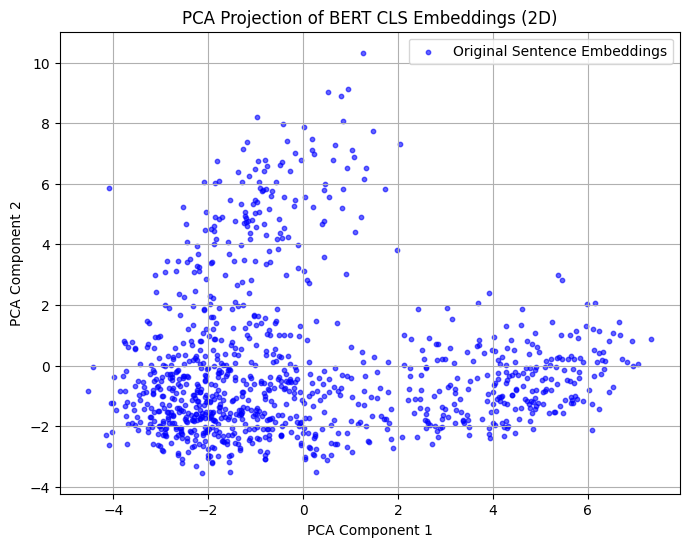

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_space[:, 0], pca_space[:, 1], alpha=0.6, s=10, c='blue', label='Original Sentence Embeddings')
plt.title("PCA Projection of BERT CLS Embeddings (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend()
plt.show()

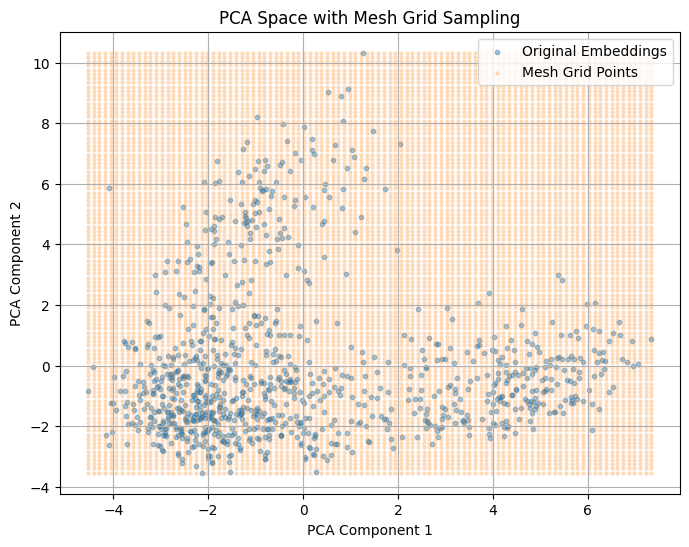

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_space[:, 0], pca_space[:, 1], alpha=0.4, s=10, label='Original Embeddings')
plt.scatter(mesh_points[:, 0], mesh_points[:, 1], alpha=0.2, s=5, label='Mesh Grid Points')
plt.title("PCA Space with Mesh Grid Sampling")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend()
plt.show()

### 4. predict the next token

In [ ]:
# 1) inverse pca to convert the format of model input (size, 768)

mesh_points_ori = pca.inverse_transform(mesh_points)

print(mesh_points_ori.shape) # (10000, 768)

(10000, 768)


In [ ]:
# 2) predict next token
import torch.nn.functional as F
# Convert mesh points to tensor
mesh_tensor = torch.tensor(mesh_points_ori, dtype=torch.float32)


batch_size = 32
num_batches = (len(mesh_tensor) + batch_size - 1) // batch_size

predicted_token_ids = []
predicted_tokens = []
max_probs = []

for i in range(num_batches):
    batch = mesh_tensor[i * batch_size: (i + 1) * batch_size]
    with torch.no_grad():
        logits = model.cls(batch)
        probs = F.softmax(logits, dim=-1)
        max_prob, pred_ids = torch.max(probs, dim=-1)
        predicted_token_ids.extend(pred_ids.tolist())
        predicted_tokens.extend(tokenizer.convert_ids_to_tokens(pred_ids.tolist()))
        max_probs.extend(max_prob.tolist())

In [ ]:
# Sanity checks
unique_tokens, counts = np.unique(predicted_tokens, return_counts=True)
top_tokens = sorted(zip(unique_tokens, counts), key=lambda x: x[1], reverse=True)[:10]

print(f"Total mesh points processed: {len(mesh_tensor)}")
print(f"Number of unique predicted tokens: {len(set(predicted_tokens))}")
print("Top 10 most frequent predicted tokens:")
for token, count in top_tokens:
    print(f"{token}: {count}")
print(f"  Max predicted probability: {max(max_probs):.4f}")
print(f"  Min predicted probability: {min(max_probs):.4f}")
print(f"  Average predicted probability: {np.mean(max_probs):.4f}")

Total mesh points processed: 10000
Number of unique predicted tokens: 3
Top 10 most frequent predicted tokens:
the: 8270
a: 1467
.: 263
  Max predicted probability: 0.0806
  Min predicted probability: 0.0172
  Average predicted probability: 0.0368


While predicting the next token over mesh grid points in the PCA-inversed space, the model mostly returns highly frequent tokens such as "the", "a", and ".". This behavior suggests that the sampled vectors do not resemble natural language context vectors that the model was trained on. As a result, the model defaults to high-probability, generic tokens when faced with "unnatural" or out-of-distribution inputs.

This reveals an important insight:

> BERT is confident in its prediction only when the input vector resembles a meaningful context it has seen during training.


The overwhelmingly low predicted probabilities (with a max around 0.08) further support this. Therefore, only a small portion of the mesh grid likely lies within the “valid region” of the model's embedding space.

### 6. visualization of clusters

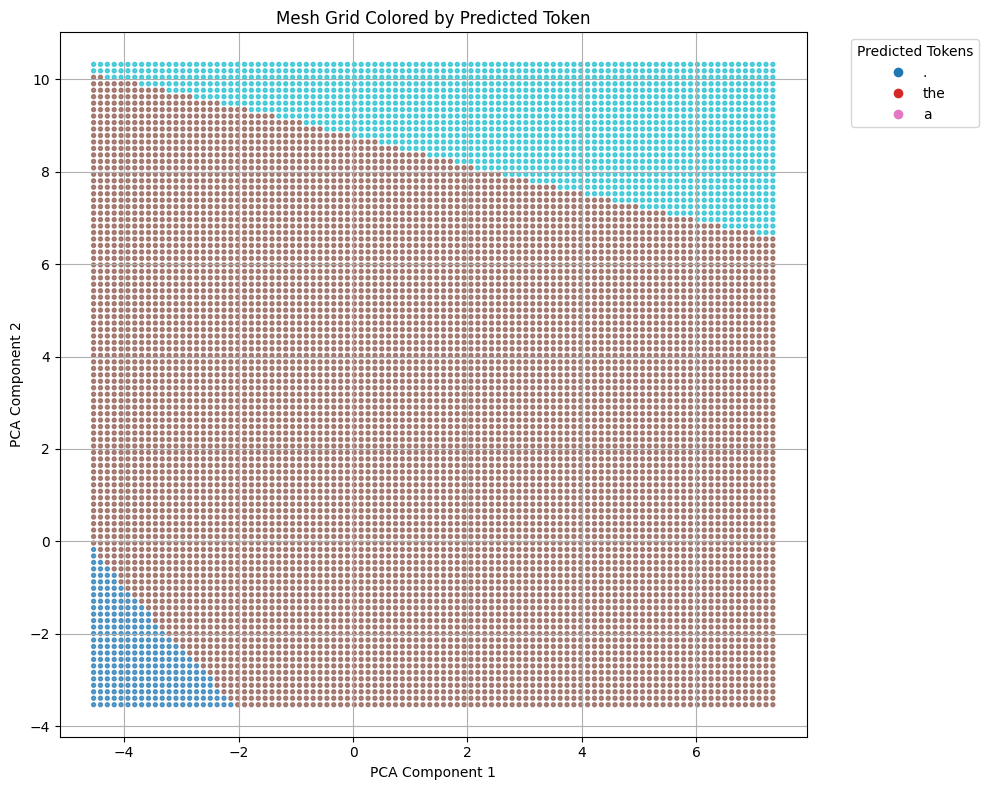

In [ ]:
import seaborn as sns

# pca_space: (1000, 2) -> location of original sentences
# mesh_points: (10000, 2) -> 2D cordination of mesh grid
# predicted_tokens: length 10000 -> predicted tokens


# encoding (for coloring)
unique_tokens = list(set(predicted_tokens))
token_to_id = {token: idx for idx, token in enumerate(unique_tokens)}
token_colors = [token_to_id[tok] for tok in predicted_tokens]

# visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(mesh_points[:, 0], mesh_points[:, 1],
                      c=token_colors, cmap='tab10', s=8, alpha=0.7)

handles = [plt.Line2D([0], [0], marker='o', color='w', label=tok,
                      markerfacecolor=scatter.cmap(token_to_id[tok]/len(unique_tokens)), markersize=8)
           for tok in unique_tokens[:10]]

plt.legend(handles=handles, title="Predicted Tokens", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Mesh Grid Colored by Predicted Token")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


### how about setting pca's parameter(n_componenent) as three?

In [ ]:
# 1. decomposition
pca_ = PCA(n_components=3) # 2D spaces (100 x 100 grid)
pca_space_3 = pca.fit_transform(final_embeddings)

# 2. Mesh point
x_min, x_max = pca_space_3[:, 0].min(), pca_space_3[:,0].max()
y_min, y_max = pca_space_3[:, 1].min(), pca_space_3[:,1].max()

x_grid_3, y_grid_3 = np.meshgrid(np.linspace(x_min, x_max, 100),
                             np.linspace(y_min, y_max, 100))

mesh_points_3 = np.vstack([x_grid_3.ravel(), y_grid_3.ravel()]).T

print(mesh_points_3.shape) # shape: (10000, 2)

(10000, 2)


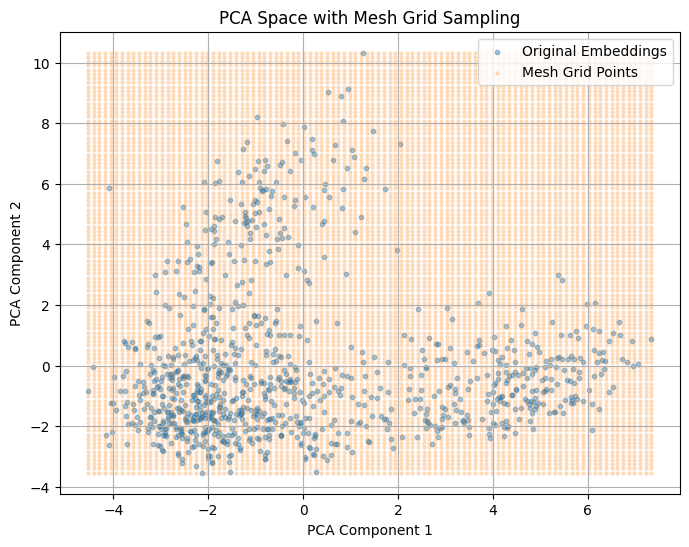

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_space_3[:, 0], pca_space_3[:, 1], alpha=0.4, s=10, label='Original Embeddings')
plt.scatter(mesh_points_3[:, 0], mesh_points_3[:, 1], alpha=0.2, s=5, label='Mesh Grid Points')
plt.title("PCA Space with Mesh Grid Sampling")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
mesh_points_ori_3 = pca.inverse_transform(mesh_points_3)

print(mesh_points_ori_3.shape) # (10000, 768)

mesh_tensor_3 = torch.tensor(mesh_points_ori_3, dtype=torch.float32)


batch_size = 32
num_batches = (len(mesh_tensor_3) + batch_size - 1) // batch_size

predicted_token_ids_3 = []
predicted_tokens_3 = []
max_probs_3 = []

for i in range(num_batches):
    batch = mesh_tensor_3[i * batch_size: (i + 1) * batch_size]
    with torch.no_grad():
        logits = model.cls(batch)
        probs = F.softmax(logits, dim=-1)
        max_prob, pred_ids = torch.max(probs, dim=-1)
        predicted_token_ids_3.extend(pred_ids.tolist())
        predicted_tokens_3.extend(tokenizer.convert_ids_to_tokens(pred_ids.tolist()))
        max_probs_3.extend(max_prob.tolist())

# Sanity checks
unique_tokens_3, counts_3 = np.unique(predicted_tokens_3, return_counts=True)
top_tokens_3 = sorted(zip(unique_tokens_3, counts_3), key=lambda x: x[1], reverse=True)[:10]

print(f"Total mesh points processed: {len(mesh_tensor_3)}")
print(f"Number of unique predicted tokens: {len(set(predicted_tokens_3))}")
print("Top 10 most frequent predicted tokens:")
for token, count in top_tokens_3:
    print(f"{token}: {count}")
print(f"  Max predicted probability: {max(max_probs_3):.4f}")
print(f"  Min predicted probability: {min(max_probs_3):.4f}")
print(f"  Average predicted probability: {np.mean(max_probs_3):.4f}")

(10000, 768)
Total mesh points processed: 10000
Number of unique predicted tokens: 3
Top 10 most frequent predicted tokens:
the: 8270
a: 1467
.: 263
  Max predicted probability: 0.0806
  Min predicted probability: 0.0172
  Average predicted probability: 0.0368


### 7. Statistics
#### (1) Point counts

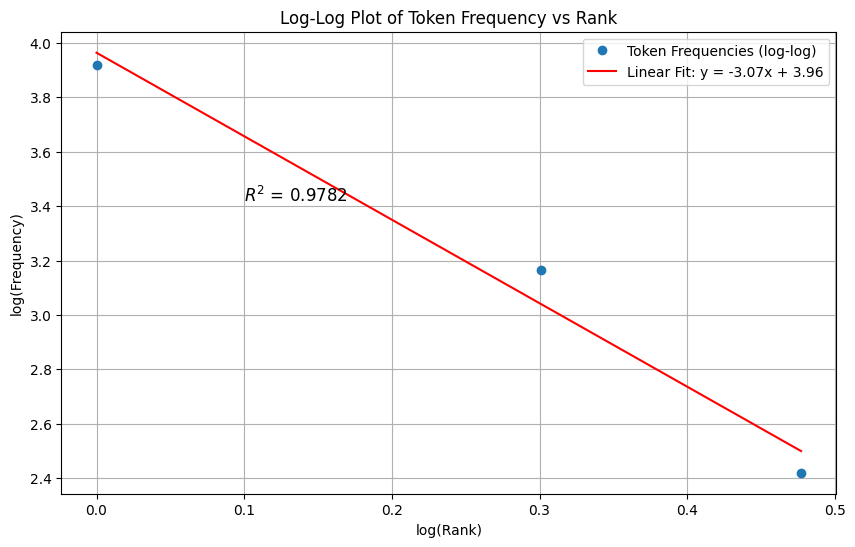

In [ ]:
from collections import Counter
from scipy.stats import linregress

# 1. Count frequencies of predicted tokens
token_counts = Counter(predicted_tokens)
sorted_counts = np.array(sorted(token_counts.values(), reverse=True))

# 2. Prepare data for log-log plot
ranks = np.arange(1, len(sorted_counts) + 1)
log_ranks = np.log10(ranks)
log_counts = np.log10(sorted_counts)

# 3. Linear regression on log-log scale
slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_counts)
fit_line = slope * log_ranks + intercept

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(log_ranks, log_counts, 'o', label='Token Frequencies (log-log)')
plt.plot(log_ranks, fit_line, 'r-', label=f'Linear Fit: y = {slope:.2f}x + {intercept:.2f}')
plt.title("Log-Log Plot of Token Frequency vs Rank")
plt.xlabel("log(Rank)")
plt.ylabel("log(Frequency)")
plt.legend()
plt.grid(True)
plt.text(0.1, max(log_counts)-0.5, f"$R^2$ = {r_value**2:.4f}", fontsize=12)
plt.show()

In [ ]:
print(token_counts)

Counter({'the': 8270, 'a': 1467, '.': 263})


#### (2) Cluster counts

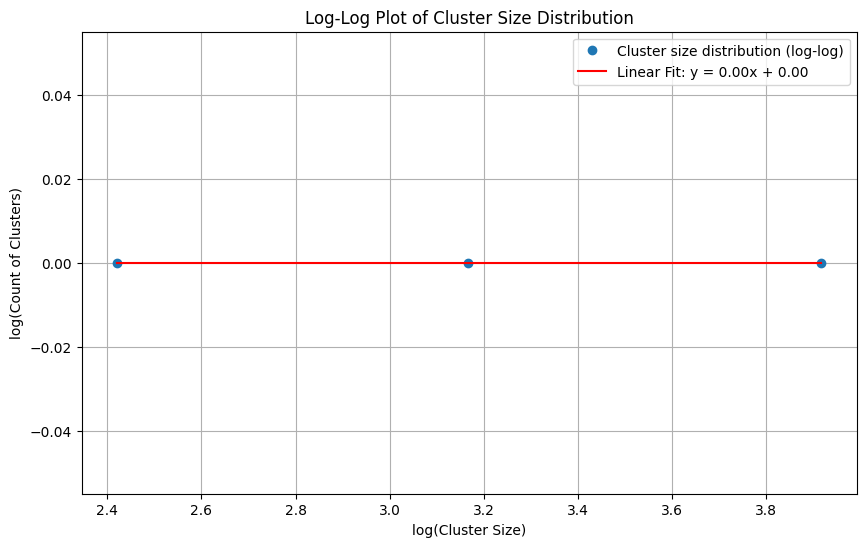

In [ ]:

# 1. Count how many points belong to each predicted token (cluster)
token_counts = Counter(predicted_tokens)

# 2. Count how many clusters have the same number of points
# This is the cluster size distribution
cluster_size_counts = Counter(token_counts.values())

# 3. Prepare data
sizes = np.array(sorted(cluster_size_counts.keys(), reverse=True))
counts = np.array([cluster_size_counts[size] for size in sizes])

# 4. Log-Log Plot and Linear Fit
log_sizes = np.log10(sizes)
log_counts = np.log10(counts)

slope, intercept, r_val, _, _ = linregress(log_sizes, log_counts)
fit_line = slope * log_sizes + intercept

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(log_sizes, log_counts, 'o', label='Cluster size distribution (log-log)')
plt.plot(log_sizes, fit_line, 'r-', label=f'Linear Fit: y = {slope:.2f}x + {intercept:.2f}')
plt.xlabel("log(Cluster Size)")
plt.ylabel("log(Count of Clusters)")
plt.title("Log-Log Plot of Cluster Size Distribution")
plt.grid(True)
plt.legend()
plt.show()